In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

            timestamp    xprice    yprice  returns                date
0       1357225500000  139.8375  169.2500   0.3125 2013-01-03 15:05:00
1       1357225510000  139.8875  169.3000   0.2750 2013-01-03 15:05:10
2       1357225520000  139.8625  169.3375   0.2500 2013-01-03 15:05:20
3       1357225530000  139.8375  169.3625   0.2375 2013-01-03 15:05:30
4       1357225540000  139.8375  169.3625   0.3250 2013-01-03 15:05:40
...               ...       ...       ...      ...                 ...
342625  1388429950000  135.2375  167.9750  -0.1250 2013-12-30 18:59:10
342626  1388429960000  135.2250  168.0250  -0.1750 2013-12-30 18:59:20
342627  1388429970000  135.2250  168.0000  -0.1500 2013-12-30 18:59:30
342628  1388429980000  135.1875  168.0125  -0.1625 2013-12-30 18:59:40
342629  1388429990000  135.1125  167.8500   0.0000 2013-12-30 18:59:50

[342630 rows x 5 columns]


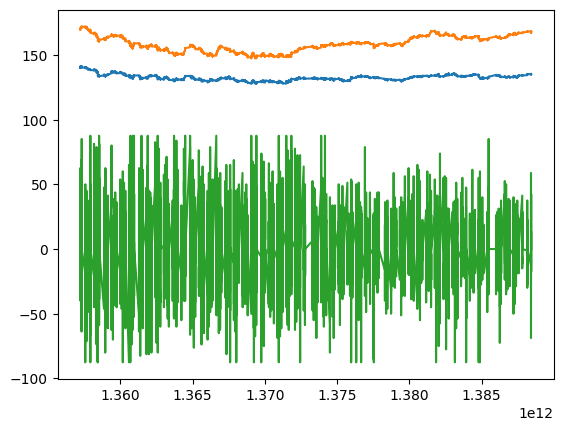

In [79]:
df = pd.read_csv("data.csv")
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
print(df)

plt.plot(df['timestamp'], df['xprice'])
plt.plot(df['timestamp'], df['yprice'])
plt.plot(df['timestamp'], 100*df['returns'])

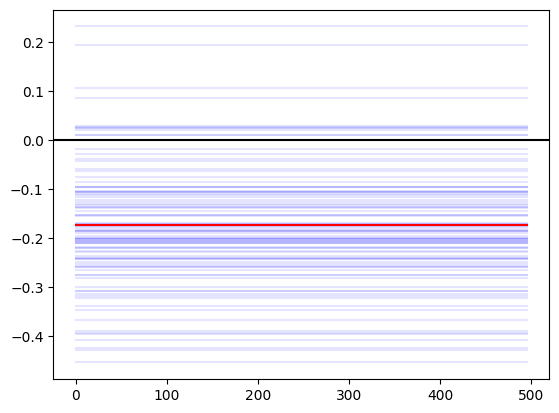

In [314]:
def plot(x, y):
    _ = plt.figure(figsize=(8, 8))
    plt.scatter(x, y, alpha=0.01)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.show()

def window(x, y, k):
    feats = np.zeros([x.shape[0] - k, k])
    print(feats.shape)
    for idx in range(k):
        feats[:, idx] = np.roll(x, idx)[k:]
    return feats, y[k:]


def diff(x, d):
    dx = np.zeros([x.shape[0],])
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx

def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    # x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats

def correlation(x, y):
    mx = np.mean(x)
    my = np.mean(y)
    cov = np.mean((x - mx)*(y - my))
    xdev = np.sqrt(np.mean((x - mx)**2))
    ydev = np.sqrt(np.mean((y - my)**2))
    return cov / (xdev * ydev)

lim = 100
coeff = 5
num_sets = 100
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
corrs = np.zeros((num_sets, lim))
for set_idx in range(num_sets):
    df_slice = df[set_idx*set_size:(set_idx+1)*set_size]
    for idx in range(corrs.shape[1]):
        x = window(df_slice['yprice'], 1, coeff * idx)
        corrs[set_idx, idx] = correlation(x[:, 0], df_slice['returns'])
    plt.plot(np.arange(0, lim*coeff, coeff), corrs[set_idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(corrs, axis=0), c='red')
plt.axhline(0, c='black')
plt.show()


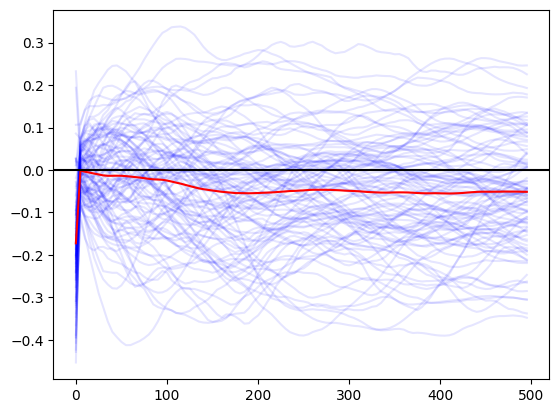

In [315]:
def plot(x, y):
    _ = plt.figure(figsize=(8, 8))
    plt.scatter(x, y, alpha=0.01)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.show()

def window(x, y, k):
    feats = np.zeros([x.shape[0] - k, k])
    print(feats.shape)
    for idx in range(k):
        feats[:, idx] = np.roll(x, idx)[k:]
    return feats, y[k:]


def diff(x, d):
    dx = np.zeros([x.shape[0],])
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx

def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats

def correlation(x, y):
    mx = np.mean(x)
    my = np.mean(y)
    cov = np.mean((x - mx)*(y - my))
    xdev = np.sqrt(np.mean((x - mx)**2))
    ydev = np.sqrt(np.mean((y - my)**2))
    return cov / (xdev * ydev)

lim = 100
coeff = 5
num_sets = 100
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
corrs = np.zeros((num_sets, lim))
for set_idx in range(num_sets):
    df_slice = df[set_idx*set_size:(set_idx+1)*set_size]
    for idx in range(corrs.shape[1]):
        x = window(df_slice['yprice'], 1, coeff * idx)
        corrs[set_idx, idx] = correlation(x[:, 0], df_slice['returns'])
    plt.plot(np.arange(0, lim*coeff, coeff), corrs[set_idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(corrs, axis=0), c='red')
plt.axhline(0, c='black')
plt.show()


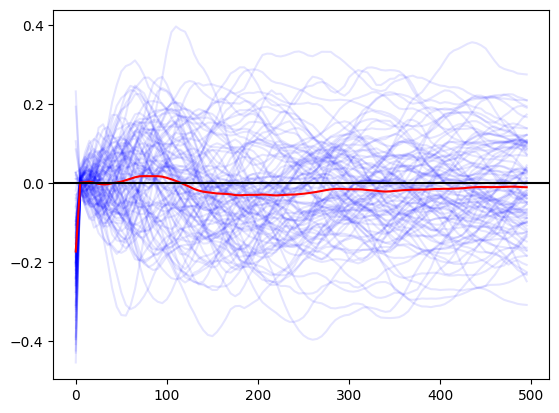

In [316]:
def plot(x, y):
    _ = plt.figure(figsize=(8, 8))
    plt.scatter(x, y, alpha=0.01)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.show()

def window(x, y, k):
    feats = np.zeros([x.shape[0] - k, k])
    print(feats.shape)
    for idx in range(k):
        feats[:, idx] = np.roll(x, idx)[k:]
    return feats, y[k:]


def diff(x, d):
    dx = np.zeros([x.shape[0],])
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx

def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    x = diff(x, d)
    x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats

def correlation(x, y):
    mx = np.mean(x)
    my = np.mean(y)
    cov = np.mean((x - mx)*(y - my))
    xdev = np.sqrt(np.mean((x - mx)**2))
    ydev = np.sqrt(np.mean((y - my)**2))
    return cov / (xdev * ydev)

lim = 100
coeff = 5
num_sets = 100
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
corrs = np.zeros((num_sets, lim))
for set_idx in range(num_sets):
    df_slice = df[set_idx*set_size:(set_idx+1)*set_size]
    for idx in range(corrs.shape[1]):
        x = window(df_slice['yprice'], 1, coeff * idx)
        corrs[set_idx, idx] = correlation(x[:, 0], df_slice['returns'])
    plt.plot(np.arange(0, lim*coeff, coeff), corrs[set_idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(corrs, axis=0), c='red')
plt.axhline(0, c='black')
plt.show()


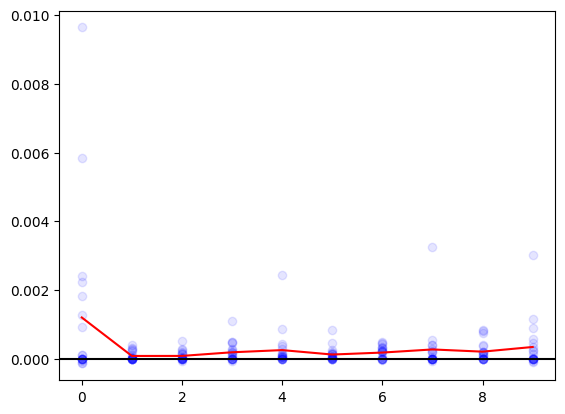

In [345]:
def diff(x, d):
    dx = np.zeros([x.shape[0],])
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx


def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats


def process_feats(df):
    feats = window(df['yprice'], K, D)
    # feats = df[['yprice']]
    # feats = np.concatenate([feats, np.ones((feats.shape[0], 1))], axis=1)
    target = np.array(df['returns'])

    return feats, target


def modelEstimate(trainingFilename):
    """
    Fit a model using historical data.

    Args:
        trainingFilename (str): path to training data. The data will
            be in the same format as the supplied `data.csv` file

    Returns:
        parameters (any): fitted model and any additional parameters
            you need to pass to modelForecast

    """

    df = pd.read_csv(trainingFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    num_slices = 12
    slice_size = int(np.ceil(len(df.index)/num_slices))
    error = np.zeros((num_slices, num_slices))
    param_list = []
    for row in range(num_slices):
        slice_df = df[row*slice_size:(row+1)*slice_size]
        feats, target = process_feats(slice_df)
        params, _, _, _ = scipy.linalg.lstsq(feats, target)
        param_list.append(params)
        for col in range(num_slices):
            slice_df = df[col*slice_size:(col+1)*slice_size]
            feats, target = process_feats(slice_df)
            pred = np.matmul(feats, params)
            error[row, col] = np.mean((pred - target)**2)
    
    best_param = param_list[np.argmin(np.amax(error, axis=1))]

    return best_param


def modelForecast(testFilename, parameters):
    """
    Predict returns using a fitted model.

    Args:
        testFilename (str): path to test data. The data will be in
            the same format as the supplied `data.csv` file
        parameters (any): fitted model and any additional parameters
            you need to make your forecasts

    Returns:
        forecast (np.array): vector of predictions. Make sure to
            return a prediction for each data point in the test set

    """

    df = pd.read_csv(testFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    feats, _ = process_feats(df)
    pred = np.matmul(feats, parameters)

    return pred


def plot(x, y, z, u):
    _ = plt.figure(figsize=(6, 6))
    plt.plot(x, y)
    plt.plot(x, z)
    plt.plot(x, u)
    plt.show()


def evaluation(testFilename, pred):
    df = pd.read_csv(testFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    # plot(df['timestamp'], pred - df['returns'], pred, df['returns'])
    error = np.mean((df['returns'] - pred)**2) - np.mean(df['returns']**2)

    return error

K = 1
D = 1

lim = 10
coeff = 1
num_sets = 20
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
errs = np.zeros((lim, num_sets))
for idx in range(lim):
    D = coeff * idx
    for set_idx in range(num_sets):
        set_idx = np.random.randint(0, num_sets)
        params = modelEstimate("data.csv")
        set_idx = np.random.randint(0, num_sets)
        pred = modelForecast("data.csv", params)
        errs[idx, set_idx] = evaluation("data.csv", pred)
    plt.scatter(np.ones((num_sets,))*idx*coeff, errs[idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(errs, axis=1), c='red')
plt.axhline(0, c='black')
plt.show()


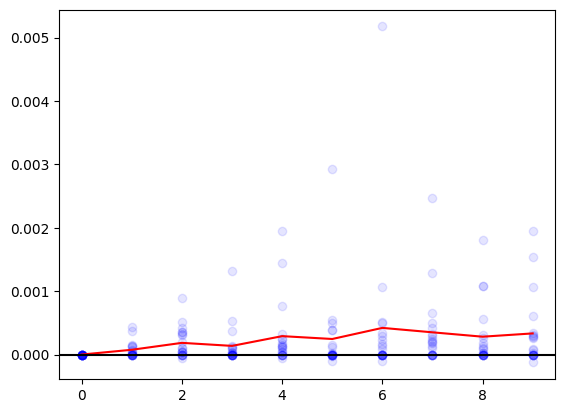

In [346]:
K = 1
D = 1

lim = 10
coeff = 1
num_sets = 20
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
errs = np.zeros((lim, num_sets))
for idx in range(lim):
    K = coeff * idx
    for set_idx in range(num_sets):
        set_idx = np.random.randint(0, num_sets)
        params = modelEstimate("data.csv")
        set_idx = np.random.randint(0, num_sets)
        pred = modelForecast("data.csv", params)
        errs[idx, set_idx] = evaluation("data.csv", pred)
    plt.scatter(np.ones((num_sets,))*idx*coeff, errs[idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(errs, axis=1), c='red')
plt.axhline(0, c='black')
plt.show()


[-4.40989229e-07]
[-4.22220108e-07]
[-4.40989229e-07]
[-4.40989229e-07]
[7.51767951e-08]
[1.15185427e-07]
[5.37186452e-07]
[7.51767951e-08]
[-4.22220108e-07]
[7.51767951e-08]
[0.0004508]
[-1.78500516e-06]
[-0.0001859]
[-0.00017474]
[0.00021486]
[-1.78500516e-06]
[-0.00028236]
[-0.00017474]
[0.00021486]
[-0.0001859]
[0.00024114]
[0.00030928]
[0.00030928]
[0.00024089]
[0.00024114]
[0.00030928]
[0.00012296]
[-0.0002279]
[0.00043114]
[-0.00016112]
[0.00028764]
[-0.00028565]
[-0.00017542]
[0.00028764]
[0.0003053]
[-0.00022052]
[0.00053258]
[-0.00022052]
[0.0003053]
[0.00040408]
[0.00027214]
[0.00020172]
[0.00027403]
[0.00053485]
[6.05635697e-06]
[0.00053485]
[6.05635697e-06]
[-0.00019457]
[0.00053485]
[0.00027214]
[0.00027003]
[0.00051297]
[0.00027003]
[0.00027003]
[-0.00043524]
[-0.00017867]
[-0.00024541]
[0.00036055]
[0.00017262]
[-0.00017354]
[0.0002896]
[-0.00016221]
[-0.00016978]
[-0.00023538]
[0.00021692]
[0.00029075]
[-0.00016978]
[0.0002896]
[0.00049821]
[-6.69517715e-05]
[0.0001862

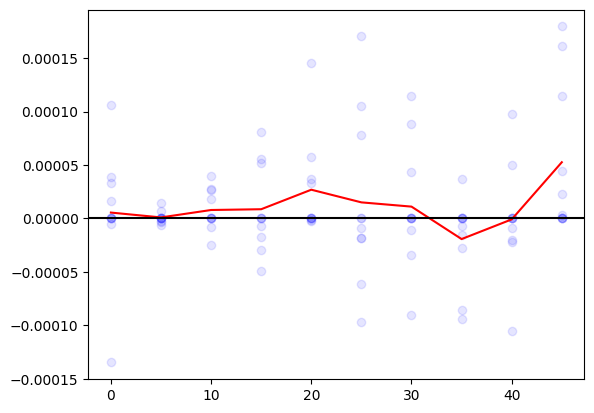

In [359]:
def diff(x, d):
    dx = np.zeros_like(x)
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx


def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats


def process_feats(df):
    feats = window(df['yprice'], K, D)
    feats = np.mean(feats, axis=1, keepdims=True) * np.expand_dims(df['yprice'], axis=1)
    target = np.array(df['returns'])

    return feats, target


def modelEstimate(trainingFilename):
    """
    Fit a model using historical data.

    Args:
        trainingFilename (str): path to training data. The data will
            be in the same format as the supplied `data.csv` file

    Returns:
        parameters (any): fitted model and any additional parameters
            you need to pass to modelForecast

    """

    df = pd.read_csv(trainingFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    feats, target = process_feats(df)
    params, _, _, _ = scipy.linalg.lstsq(feats, target)

    return params


def modelForecast(testFilename, parameters):
    """
    Predict returns using a fitted model.

    Args:
        testFilename (str): path to test data. The data will be in
            the same format as the supplied `data.csv` file
        parameters (any): fitted model and any additional parameters
            you need to make your forecasts

    Returns:
        forecast (np.array): vector of predictions. Make sure to
            return a prediction for each data point in the test set

    """

    df = pd.read_csv(testFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    feats, _ = process_feats(df)
    pred = np.matmul(feats, parameters)

    return pred


def plot(x, y, z, u):
    _ = plt.figure(figsize=(6, 6))
    plt.plot(x, y)
    plt.plot(x, z)
    plt.plot(x, u)
    plt.show()


def evaluation(testFilename, pred):
    df = pd.read_csv(testFilename)
    df = df[set_idx*set_size:(set_idx+1)*set_size]
    # plot(df['timestamp'], pred - df['returns'], pred, df['returns'])
    error = np.mean((df['returns'] - pred)**2) - np.mean(df['returns']**2)

    return error


K = 1
D = 1

lim = 10
coeff = 5
num_sets = 10
df = pd.read_csv("data.csv")
set_size = int(np.ceil(len(df.index) / num_sets))
errs = np.zeros((lim, num_sets))
for idx in range(lim):
    D = coeff * idx
    for set_idx in range(num_sets):
        set_idx = np.random.randint(0, num_sets)
        params = modelEstimate("data.csv")
        print(params)
        set_idx = np.random.randint(0, num_sets)
        pred = modelForecast("data.csv", params)
        errs[idx, set_idx] = evaluation("data.csv", pred)
    plt.scatter(np.ones((num_sets,))*idx*coeff, errs[idx], c='blue', alpha=0.1)
plt.plot(np.arange(0, lim*coeff, coeff), np.mean(errs, axis=1), c='red')
plt.axhline(0, c='black')
plt.show()


In [ ]:
def diff(x, d):
    dx = np.zeros_like(x)
    kernel = np.zeros((d+1,))
    kernel[-1] = -1
    kernel[0] = 1
    if x.shape[0] > d:
        dx[d:] = np.convolve(x, kernel, mode='valid')

    return dx


def window(x, k, d):
    feats = np.zeros([x.shape[0], k])
    x = diff(x, d)
    for idx in range(k):
        feats[d*idx:, idx] = np.roll(x, d*idx)[d*idx:]

    return feats


def process_feats(df):
    k = 1
    d = 60
    feats = window(df['yprice'], k, d)
    feats = np.mean(feats, axis=1, keepdims=True) * \
        np.expand_dims(df['yprice'], axis=1)
    target = np.array(df['returns'])

    return feats, target


def modelEstimate(trainingFilename):
    """
    Fit a model using historical data.

    Args:
        trainingFilename (str): path to training data. The data will
            be in the same format as the supplied `data.csv` file

    Returns:
        parameters (any): fitted model and any additional parameters
            you need to pass to modelForecast

    """

    df = pd.read_csv(trainingFilename)
    feats, target = process_feats(df)
    params, _, _, _ = scipy.linalg.lstsq(feats, target)

    return params


def modelForecast(testFilename, parameters):
    """
    Predict returns using a fitted model.

    Args:
        testFilename (str): path to test data. The data will be in
            the same format as the supplied `data.csv` file
        parameters (any): fitted model and any additional parameters
            you need to make your forecasts

    Returns:
        forecast (np.array): vector of predictions. Make sure to
            return a prediction for each data point in the test set

    """

    df = pd.read_csv(testFilename)
    feats, _ = process_feats(df)
    pred = np.matmul(feats, parameters)

    return pred


I am submitting the following linear model (described in LaTeX math notation for clarity):

$$R_t = \theta ~ Y_t ~ \frac{1}{K} \sum_k^K R_{t - 60 * k}$$

$R_t = Y_{t + 60} - Y_t$ is the future return of stock $Y$ at time $t$. $Y_t$ is the price of stock $Y$ at time $t$. $K$ is a hyperparameter. $\theta$ is the regression parameter. The number 60 denotes the 60 timesteps that comprise 10 minutes.

This model predicts the future return as a function of the average return from the $K$ previous 10-minute intervals. The new return should be proportional to the current price of the stock, so the average is scaled by the current stock price. I use an extra learned scaling parameter $\theta$.

The value of $K = 3$ was found by hyperparameter search.

This model barely outperforms the obvious baseline of $R_t = 0$, but it is the best performing model among the variety of linear models that I've experimented with.